# Порядок выполнения проектной работы
### 1. Сбор и очистка данных
### 2. Анализ данных
### 3. Создание модели
### 4. Оценка качества модели




# <b>Сбор и очистка данных</b>

Парсер находится в файле parser.py и собирает данные с сайта mirkvartir.ru. Соберем 10000 предложений со случайных страниц сайта. Сохраняем в файл main_data10000.csv. Собранные объекты имеют слудующие параметры:

id - идентификатор;<br>
url - ссылка на предложение;<br>
title - заголовок;<br>
price - стоимость аренды за месяц;<br>
laltitude - широта в координатах;<br>
longitude - долгота в координатах;<br>
metro_name - название ближайшей станции метро;<br>
metro_distanse - расстояние до метро в минутах;<br>
distanceType - тип транспорта, на котором можно добраться до метро за указанное  количество минут;<br>
update_time - время последнего обновления предложения.
<br><br>
По ожиданиям, цена аренды должна больше всего зависеть от площади квартиры, расстояния до метро и этажа. Соберем данные и посмотрим зависимости на графиках.

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive/


In [ ]:
import pandas as pd
import numpy as np
offers = pd.read_csv('main_data10000.csv')
print(len(offers))
offers.head(5)

10000


,id,url,title,price,latitude,longitude,metro_name,metro_distance,distanceType,update_time
0,348929935,https://arenda.mirkvartir.ru/348929935/,"3-комн. квартира, 80 м2, 5/5 этаж",105000,59.987354,30.294416,Пионерская,NaN,0.000000,2025-08-26T20:20:57
1,349962437,https://arenda.mirkvartir.ru/349962437/,"4-комн. квартира, 170 м2, 5/5 этаж",300000,59.934032,30.340858,Лиговский проспект,NaN,0.000000,2025-09-12T19:04:29
2,349277934,https://arenda.mirkvartir.ru/349277934/,"2-комн. квартира, 51 м2, 4/9 этаж",50000,59.916557,30.479397,Улица Дыбенко,NaN,0.000000,2025-08-21T01:41:03
3,350633681,https://arenda.mirkvartir.ru/350633681/,"3-комн. квартира, 74.7 м2, 5/6 этаж",160000,59.968624,30.312634,Горьковская,NaN,0.000000,2025-09-26T07:10:00
4,349962462,https://arenda.mirkvartir.ru/349962462/,"3-комн. квартира, 120 м2, 2/4 этаж",330000,59.936436,30.326288,Сенная площадь,NaN,0.000000,2025-09-12T13:40:32


In [ ]:
offers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10000 non-null  int64  
 1   url             10000 non-null  object 
 2   title           10000 non-null  object 
 3   price           10000 non-null  int64  
 4   latitude        10000 non-null  float64
 5   longitude       10000 non-null  float64
 6   metro_name      7450 non-null   object 
 7   metro_distance  1016 non-null   float64
 8   distanceType    7450 non-null   float64
 9   update_time     10000 non-null  object 
dtypes: float64(4), int64(2), object(4)
memory usage: 781.4+ KB


Видим, что из 10000 записей только 7450 имеют заполненное поле metro_name, 7450 - distanceType, 1016 - metro_distance.

На сайте расстояние до метро представлено в неудобном формате времени, к тому же, время может измеряться относительно поездки на транспорте или пешего прохода. Нужно привести данные к единому объективному формату. Поле metro_distance заполнено всего у 1016 строк, но metro_name - у 7450. Лучше самостоятельно посчитать расстояние от квартиры до станции - таким образом сохраним больше данных и приведем их к объективным единицам измерения.

Очистим строки без упоминания станции метро.

In [ ]:
def filter_drop_metroname(offers_file: str, output_file: str) -> None:
    """
    функция чистит данные от ненужной информации и строк с пропусками
    :param stations_file: json файл с информацией о станциях метро
    :param offers_file: csv файл с объявлениями
    :param output_file: csv файл вывода данных
    :return: None
    """

    offers = pd.read_csv(offers_file)
    offers = offers.dropna(subset=['metro_name'])

    offers.to_csv(output_file, index=False)
    return None


filter_drop_metroname("main_data10000.csv", 'data_filter1.csv')
offers = pd.read_csv('data_filter1.csv')
print(len(offers))

7450


Информация о площади, количестве комнат и этаже содержитсяв едином заголовке. Парсим строку и разделяем данные на столбцы.

In [ ]:
def filter_parse_strings(offers_file: str, output_file: str):
    offers = pd.read_csv(offers_file)
    rooms = []
    area = []
    floor = []
    max_floor = []
    for i in range(len(offers)):
        offer = offers.iloc[i]
        room, ar, fl = offer.title.split(', ')
        if room == 'Студия':
            room = 0
        else:
            room = int(room[0])

        ar = float(ar.split()[0])
        if '/' not in fl:
          mx_fl = np.nan
        else:
          mx_fl = int(fl.split()[0].split('/')[1])
        fl = int(fl.split()[0].split('/')[0])
        rooms.append(room)
        area.append(ar)
        floor.append(fl)
        max_floor.append(mx_fl)

    offers['rooms'] = rooms
    offers['area'] = area
    offers['floor'] = floor
    offers['max_floor'] = max_floor
    offers = offers.dropna(subset=['max_floor'])
    offers['max_floor'] = offers['max_floor'].astype(int)
    offers['price_per_sqm'] = offers['price'] / offers['area']
    offers.to_csv(output_file, index=False)

    return None


filter_parse_strings('data_filter1.csv', 'data_filter2.csv')
offers = pd.read_csv('data_filter2.csv')
print(len(offers))
offers.head(5)

7443


,id,url,title,price,latitude,longitude,metro_name,metro_distance,distanceType,update_time,rooms,area,floor,max_floor,price_per_sqm
0,348929935,https://arenda.mirkvartir.ru/348929935/,"3-комн. квартира, 80 м2, 5/5 этаж",105000,59.987354,30.294416,Пионерская,NaN,0.000000,2025-08-26T20:20:57,3,80.000000,5,5,1312.500000
1,349962437,https://arenda.mirkvartir.ru/349962437/,"4-комн. квартира, 170 м2, 5/5 этаж",300000,59.934032,30.340858,Лиговский проспект,NaN,0.000000,2025-09-12T19:04:29,4,170.000000,5,5,1764.705882
2,349277934,https://arenda.mirkvartir.ru/349277934/,"2-комн. квартира, 51 м2, 4/9 этаж",50000,59.916557,30.479397,Улица Дыбенко,NaN,0.000000,2025-08-21T01:41:03,2,51.000000,4,9,980.392157
3,350633681,https://arenda.mirkvartir.ru/350633681/,"3-комн. квартира, 74.7 м2, 5/6 этаж",160000,59.968624,30.312634,Горьковская,NaN,0.000000,2025-09-26T07:10:00,3,74.700000,5,6,2141.900937
4,349962462,https://arenda.mirkvartir.ru/349962462/,"3-комн. квартира, 120 м2, 2/4 этаж",330000,59.936436,30.326288,Сенная площадь,NaN,0.000000,2025-09-12T13:40:32,3,120.000000,2,4,2750.000000


Вычислим расстояние от квартиры до метро в метрах при помощи координат ближайшей станции, найденных в открытом доступе (stations.json).

In [ ]:
import math
from geopy.distance import geodesic


def add_metro_distance(stations_file: str, offers_file: str, output_file: str) -> None:
    """
    функция добавляет к каждому объявлению расстояние от
    квартиры до метро в координатах
    :param stations_file: json файл с информацией о станциях метро
    :param offers_file: csv файл с объявлениями
    :return: None
    """
    stations = pd.read_json(stations_file)
    offers = pd.read_csv(offers_file)
    metro_distance = []
    for i in range(len(offers)):
        offer = offers.iloc[i]
        if type(offer.metro_name) != float:
            flat_cords = (float(offer.latitude), float(offer.longitude))
            st = stations.loc[stations.Name == offer.metro_name]
            if len(st) == 0:
                metro_distance.append(-1)
                continue
            st = st.iloc[0]
            metro_cords = (float(st.Lat), float(st.Lon))
            metro_distance.append(geodesic((offer.latitude, offer.longitude), metro_cords).meters)
        else:
            metro_distance.append(-1)

    offers["metro_dist"] = metro_distance
    offers.to_csv(output_file, index=False)
    return None


add_metro_distance("stations.json", "data_filter2.csv", 'data_filter3.csv')
offers = pd.read_csv('data_filter3.csv')
offers.head(5)

,id,url,title,price,latitude,longitude,metro_name,metro_distance,distanceType,update_time,rooms,area,floor,max_floor,price_per_sqm,metro_dist
0,348929935,https://arenda.mirkvartir.ru/348929935/,"3-комн. квартира, 80 м2, 5/5 этаж",105000,59.987354,30.294416,Пионерская,NaN,0.000000,2025-08-26T20:20:57,3,80.000000,5,5,1312.500000,1710.593895
1,349962437,https://arenda.mirkvartir.ru/349962437/,"4-комн. квартира, 170 м2, 5/5 этаж",300000,59.934032,30.340858,Лиговский проспект,NaN,0.000000,2025-09-12T19:04:29,4,170.000000,5,5,1764.705882,1682.987238
2,349277934,https://arenda.mirkvartir.ru/349277934/,"2-комн. квартира, 51 м2, 4/9 этаж",50000,59.916557,30.479397,Улица Дыбенко,NaN,0.000000,2025-08-21T01:41:03,2,51.000000,4,9,980.392157,1037.616074
3,350633681,https://arenda.mirkvartir.ru/350633681/,"3-комн. квартира, 74.7 м2, 5/6 этаж",160000,59.968624,30.312634,Горьковская,NaN,0.000000,2025-09-26T07:10:00,3,74.700000,5,6,2141.900937,1434.014499
4,349962462,https://arenda.mirkvartir.ru/349962462/,"3-комн. квартира, 120 м2, 2/4 этаж",330000,59.936436,30.326288,Сенная площадь,NaN,0.000000,2025-09-12T13:40:32,3,120.000000,2,4,2750.000000,1085.846428


Избавимся от ненужных столбцов и обезличим данные.

In [ ]:
def filter_only_for_training(input_file, output_file):
    offers = pd.read_csv(input_file)

    offers.drop('title', axis=1, inplace=True)
    offers.drop('url', axis=1, inplace=True)
    offers.drop('metro_distance', axis=1, inplace=True)
    offers.drop('distanceType', axis=1, inplace=True)
    offers.drop('update_time', axis=1, inplace=True)
    offers.drop('metro_name', axis=1, inplace=True)

    offers.to_csv(output_file, index=False)
    return None


filter_only_for_training('data_filter3.csv', 'data_filter4.csv')
offers = pd.read_csv('data_filter4.csv')
offers.head(5)


,id,price,latitude,longitude,rooms,area,floor,max_floor,price_per_sqm,metro_dist
0,348929935,105000,59.987354,30.294416,3,80.000000,5,5,1312.500000,1710.593895
1,349962437,300000,59.934032,30.340858,4,170.000000,5,5,1764.705882,1682.987238
2,349277934,50000,59.916557,30.479397,2,51.000000,4,9,980.392157,1037.616074
3,350633681,160000,59.968624,30.312634,3,74.700000,5,6,2141.900937,1434.014499
4,349962462,330000,59.936436,30.326288,3,120.000000,2,4,2750.000000,1085.846428


Сбор данных происходил со случайных страниц, поэтому не исключены дубликаты строк. Найдем и очистим их.

In [ ]:
print(offers.duplicated().sum())
offers = offers.drop_duplicates()
print(offers.duplicated().sum())
print(len(offers))
offers.to_csv('data_filter5.csv', index=False)

2732
0
4711


## <b>Анализ данных</b>

Посмотрим распределение данных и проанализируем выбросы, которые плохо повлияют на модель.

In [ ]:
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
offers.describe(percentiles=[.01, .25, .5, .75, .99]).T



,count,mean,std,min,1%,25%,50%,75%,99%,max
id,4711.000000,350919162.026958,17856370.162508,209090582.000000,259204433.400000,350633530.500000,357403270.000000,358560787.000000,359169516.200000,359202152.000000
price,4711.000000,61321.917003,61633.557447,12000.000000,22000.000000,35000.000000,45000.000000,65000.000000,300000.000000,1602300.000000
latitude,4711.000000,59.941074,0.071450,59.654845,59.812392,59.881022,59.937873,59.999116,60.076568,60.127194
longitude,4711.000000,30.338415,0.086532,29.856236,30.108301,30.283389,30.335434,30.402936,30.513987,30.612438
rooms,4711.000000,1.356824,1.068083,0.000000,0.000000,1.000000,1.000000,2.000000,4.000000,9.000000
area,4711.000000,49.238039,34.040183,10.000000,15.000000,31.000000,41.000000,57.500000,172.900000,1000.000000
floor,4711.000000,6.800467,4.982910,1.000000,1.000000,3.000000,5.000000,9.000000,22.000000,28.000000
max_floor,4711.000000,12.365103,6.411541,1.000000,3.000000,7.000000,11.000000,16.000000,27.000000,35.000000
price_per_sqm,4711.000000,1263.561446,511.463915,67.979372,588.340336,909.090909,1128.404669,1500.000000,3000.000000,5045.871560
metro_dist,4711.000000,1833.611597,2508.067365,83.033671,215.486004,1031.427181,1481.294779,1830.051585,14725.019651,35539.094183


**1. Ценовые показатели (price):**

Средняя цена 61,321 руб, но есть экстремальные выбросы (макс 1,6 млн руб). 99% цен ниже 300,000 руб, что разумно для аренды. Медиана 45,000 руб показывает правостороннюю асимметрию.

**2. Географические координаты (latitude, longitude):**

Разброс координат соответствует границам СПб. Среднее положение (59.94, 30.33) - центр города. Стандартные отклонения малы (0.071 и 0.087), что говорит о хорошей географической кластеризации данных.

**3. Характеристики жилья:**

rooms: Медиана 1 комната, 75% квартир имеют ≤2 комнаты.

area: Средняя площадь 49.24 м², но в 99% входят и крупные объекты (172.9 м²).

Этажность: медианные значения floor=5 и max_floor=11 типичны для СПб.

**4. Расстояние до метро:**

metro_dist: Медиана 1481 м, но в 99% входит и 14.725 км - явные выбросы.


Экстремальные выбросы в price (1.6 млн).
Широкий разброс в metro_dist (от 83 м до 35.5 км).
Расхождение между средним и медианным price (61,321 vs 45,000) указывает на ненормальное распределение.

<br>

Рынок аренды в основном представлен 1-2 комнатными квартирами (~50 м²).

50% квартир расположены в 1.48 км от метро.

Геоданные показывают хорошее покрытие по всему городу без явных "дыр".



Отфильтруем выбросы:

In [ ]:
price_lower = offers['price'].quantile(0.01)
price_upper = offers['price'].quantile(0.99)
metro_max = offers['metro_dist'].quantile(0.99)
max_area = offers['area'].quantile(0.995)

offers_filtered = offers[
    (offers['price'] >= price_lower) &
    (offers['price'] <= price_upper) &
    (offers['metro_dist'] <= metro_max) &
    (offers['area'] <= max_area)
].copy()

print(f"Удалено {len(offers) - len(offers_filtered)} строк (выбросы по цене и расстоянию до метро)")
offers_filtered.to_csv('final_data.csv', index=False)

Удалено 148 строк (выбросы по цене и расстоянию до метро)


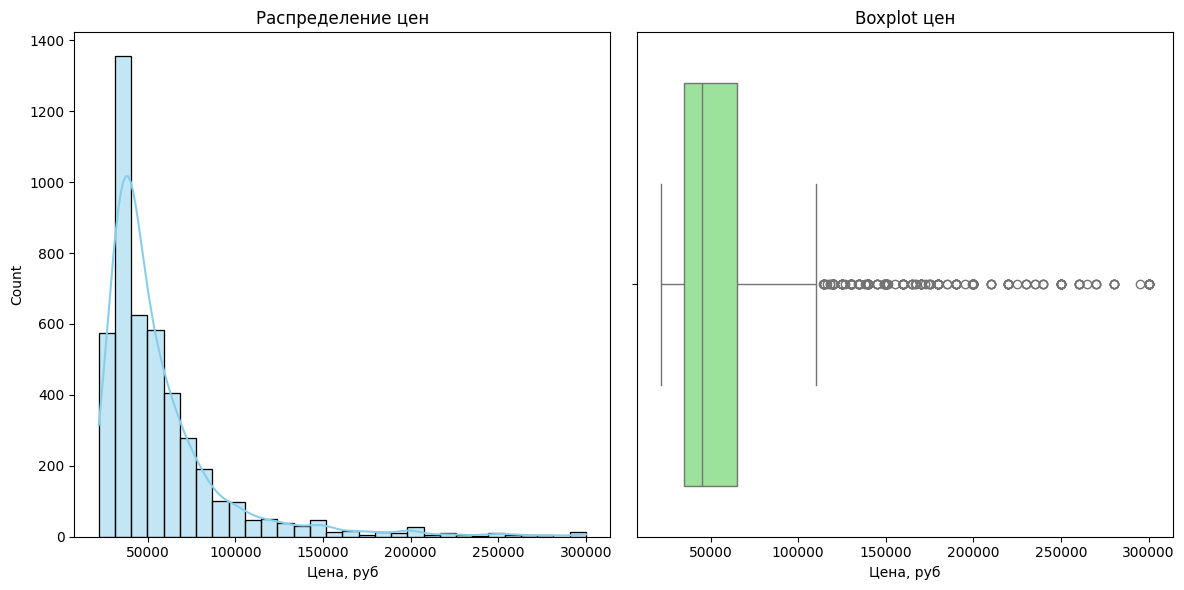

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(offers_filtered['price'], bins=30, kde=True, color='skyblue')
plt.title("Распределение цен")
plt.xlabel("Цена, руб")

plt.subplot(1, 2, 2)
sns.boxplot(x=offers_filtered['price'], color='lightgreen')
plt.title("Boxplot цен")
plt.xlabel("Цена, руб")
plt.tight_layout()
plt.show()

Распределение цен имеет правостороннюю асимметрию, то есть большинство цен сосредоточено в нижнем диапазоне (около 50,000 руб), а затем резко уменьшается. Наблюдается постепенное уменьшение количества по мере увеличения цен, с редкими высокими значениями. Ящик показывает, что 50% данных лежат в относительно узком диапазоне.

/tmp/ipykernel_26032/1612498184.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rooms', y='price', data=room_price, ax=axes[0, 1], palette='Blues_d')


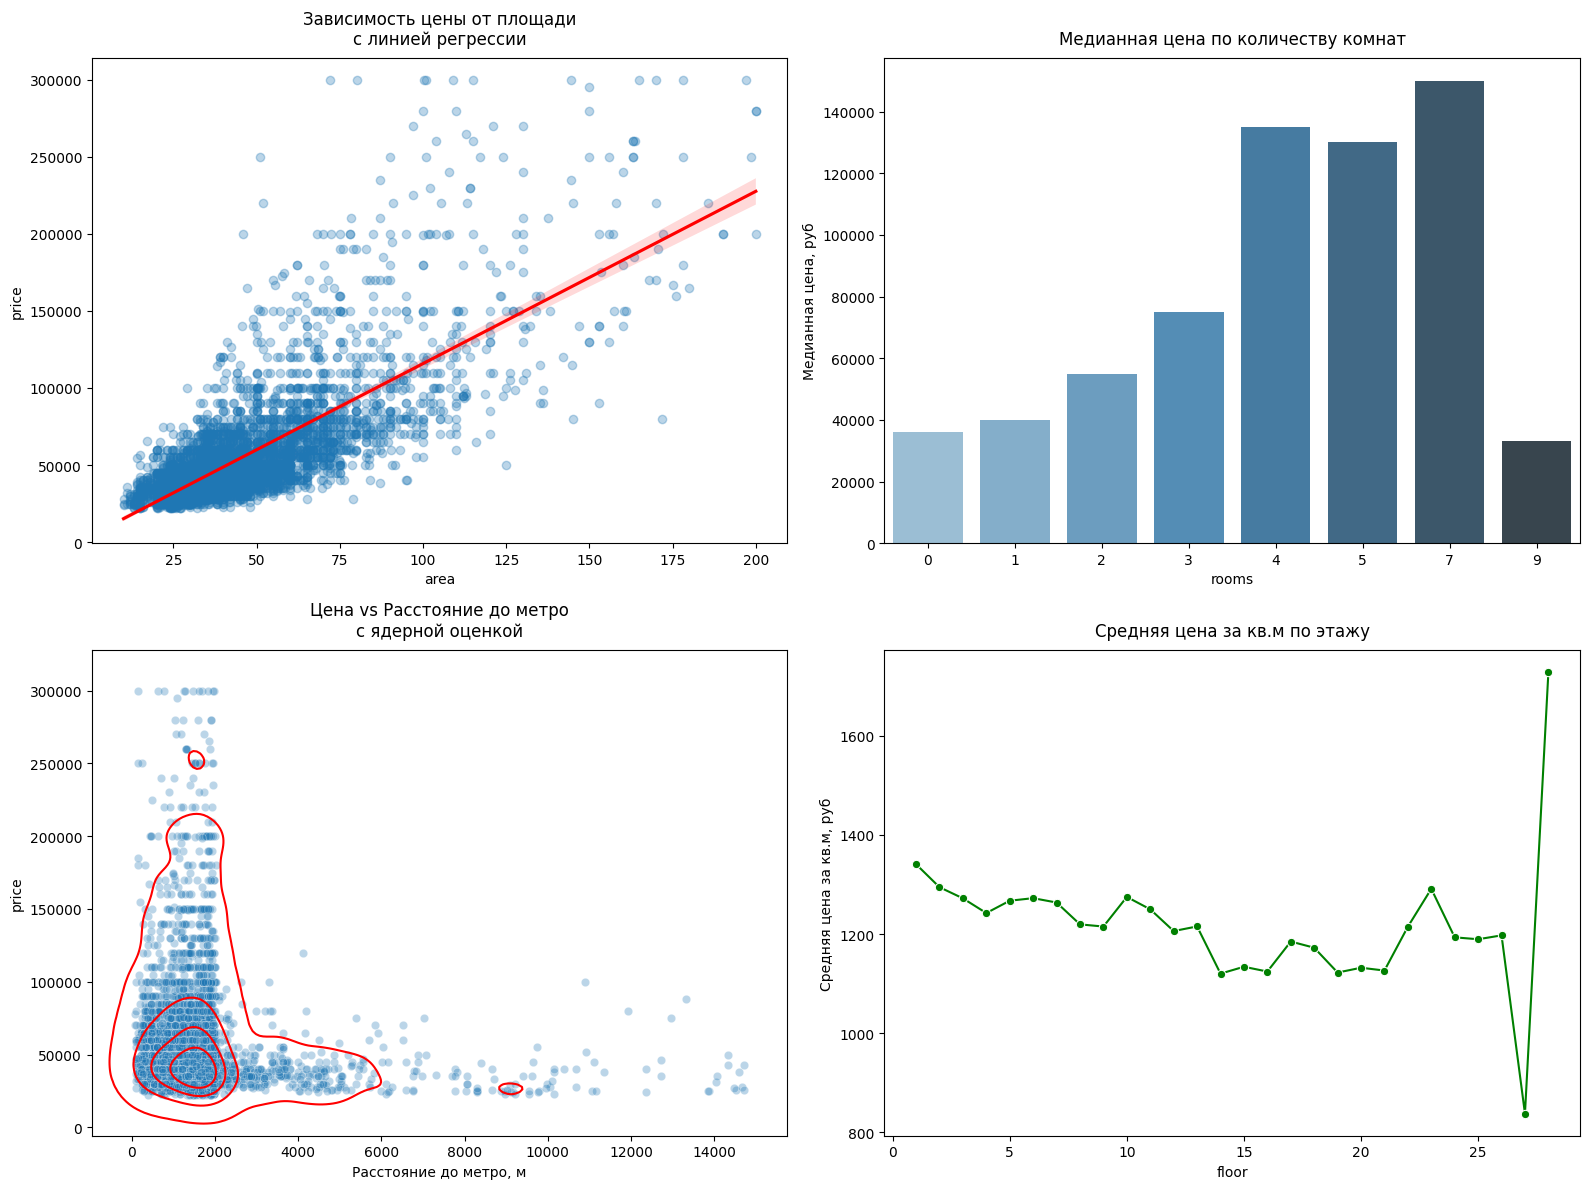

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.regplot(x='area', y='price', data=offers_filtered,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'},
            ax=axes[0, 0])
axes[0, 0].set_title("Зависимость цены от площади\nс линией регрессии", pad=10)

room_price = offers_filtered.groupby('rooms')['price'].median().reset_index()
sns.barplot(x='rooms', y='price', data=room_price, ax=axes[0, 1], palette='Blues_d')
axes[0, 1].set_title("Медианная цена по количеству комнат", pad=10)
axes[0, 1].set_ylabel("Медианная цена, руб")

sns.scatterplot(x='metro_dist', y='price', data=offers_filtered,
                alpha=0.3, ax=axes[1, 0])
sns.kdeplot(x='metro_dist', y='price', data=offers_filtered,
            levels=5, color='red', ax=axes[1, 0])
axes[1, 0].set_title("Цена vs Расстояние до метро\nс ядерной оценкой", pad=10)
axes[1, 0].set_xlabel("Расстояние до метро, м")
floor_price = offers_filtered.groupby('floor')['price_per_sqm'].mean().reset_index()
sns.lineplot(x='floor', y='price_per_sqm', data=floor_price,
             marker='o', ax=axes[1, 1], color='green')
axes[1, 1].set_title("Средняя цена за кв.м по этажу", pad=10)
axes[1, 1].set_ylabel("Средняя цена за кв.м, руб")
plt.tight_layout()
plt.show()

Наблюдается положительная корреляция между площадью и ценой: с увеличением площади цена также увеличивается. Линия регрессии показывает общую тенденцию роста цен с увеличением площади, хотя есть разброс данных, особенно на больших площадях.

Медианная цена увеличивается с ростом количества комнат. Особенно заметен рост цен на квартиры с 4 и 7 комнатами.

Наибольшая концентрация более дорогих объектов находится вблизи метро (до 2000 м). С увеличением расстояния от метро цены, как правило, снижаются.

Видно, что средняя цена за квадратный метр варьируется в зависимости от этажа. Есть пики на некоторых этажах, что может быть связано с предпочтениями покупателей или особенностями конкретных зданий на этих этажах.

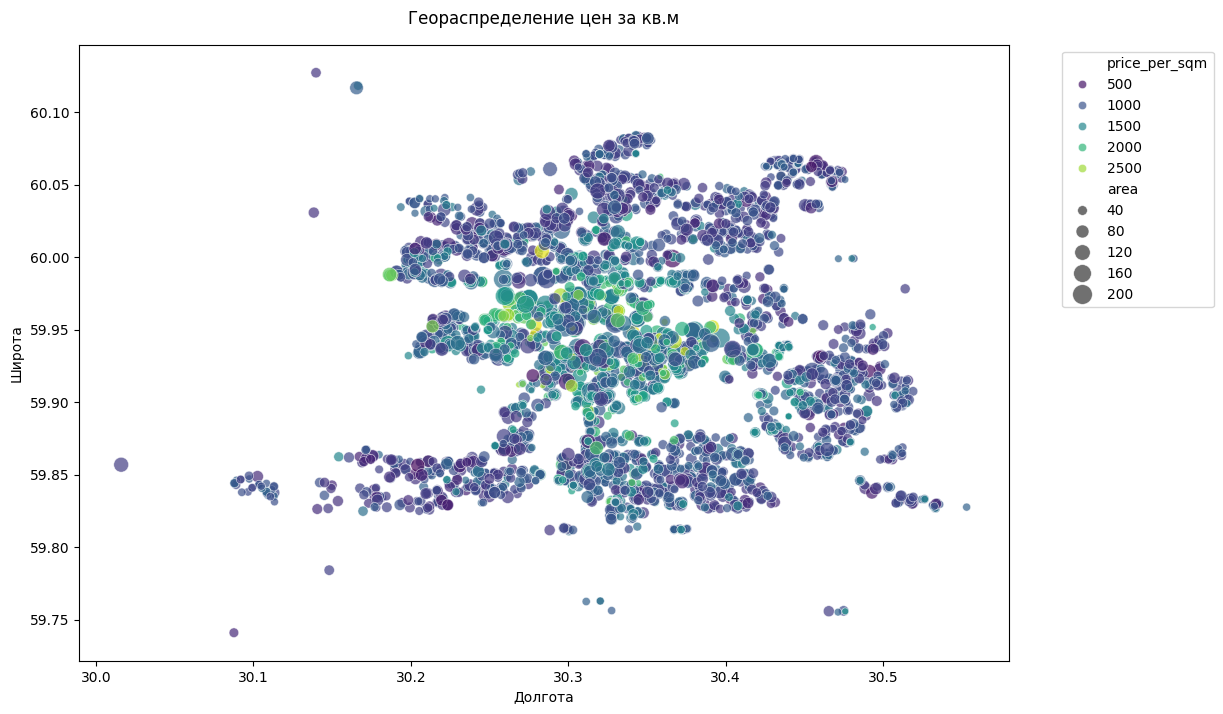

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='longitude', y='latitude',
    hue='price_per_sqm',
    size='area',
    sizes=(20, 200),
    palette='viridis',
    alpha=0.7,
    data=offers_filtered[offers_filtered['price_per_sqm'] <= offers_filtered['price_per_sqm'].quantile(0.99)]
)
plt.title("Геораспределение цен за кв.м", pad=15)
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Размер точек указывает на площадь объекта. Более крупные точки представляют большие площади. Видно, что более крупные объекты присутствуют в разнообразных ценовых сегментах.

Основная концентрация объектов находится в центральных районах, где наблюдаются более высокие цены. В отдалённых районах цены, как правило, ниже, что видно по преобладанию фиолетовых точек.

Можно заметить концентрацию более дорогих квартир в центре, имеет смыст добавить признак расстояния до центра города, найденного из статистических данных.

In [ ]:
from geopy.distance import geodesic


def add_centre_distance(offers_file: str, output_file: str) -> None:
    """
    функция добавляет к каждому объявлению расстояние от
    квартиры до метро в координатах
    :param stations_file: json файл с информацией о станциях метро
    :param offers_file: csv файл с объявлениями
    :return: None
    """
    offers = pd.read_csv(offers_file)
    centre_distance = []
    for i in range(len(offers)):
        offer = offers.iloc[i]
        flat_cords = (float(offer.latitude), float(offer.longitude))
        centre_coords = (59.94, 30.33)
        centre_distance.append(geodesic((offer.latitude, offer.longitude), centre_coords).meters)

    offers['centre_distance'] = centre_distance
    offers.to_csv(output_file, index=False)
    return None


add_centre_distance("final_data.csv", 'final_data2.csv')
offers_filtered = pd.read_csv('final_data2.csv')
offers_filtered.head(5)

,id,price,latitude,longitude,rooms,area,floor,max_floor,price_per_sqm,metro_dist,centre_distance
0,348929935,105000,59.987354,30.294416,3,80.000000,5,5,1312.500000,1710.593895,5637.831363
1,349962437,300000,59.934032,30.340858,4,170.000000,5,5,1764.705882,1682.987238,900.320763
2,349277934,50000,59.916557,30.479397,2,51.000000,4,9,980.392157,1037.616074,8753.133487
3,350633681,160000,59.968624,30.312634,3,74.700000,5,6,2141.900937,1434.014499,3333.405380
4,349279279,50000,60.021023,30.381040,2,45.600000,3,9,1096.491228,1467.568499,9466.060305


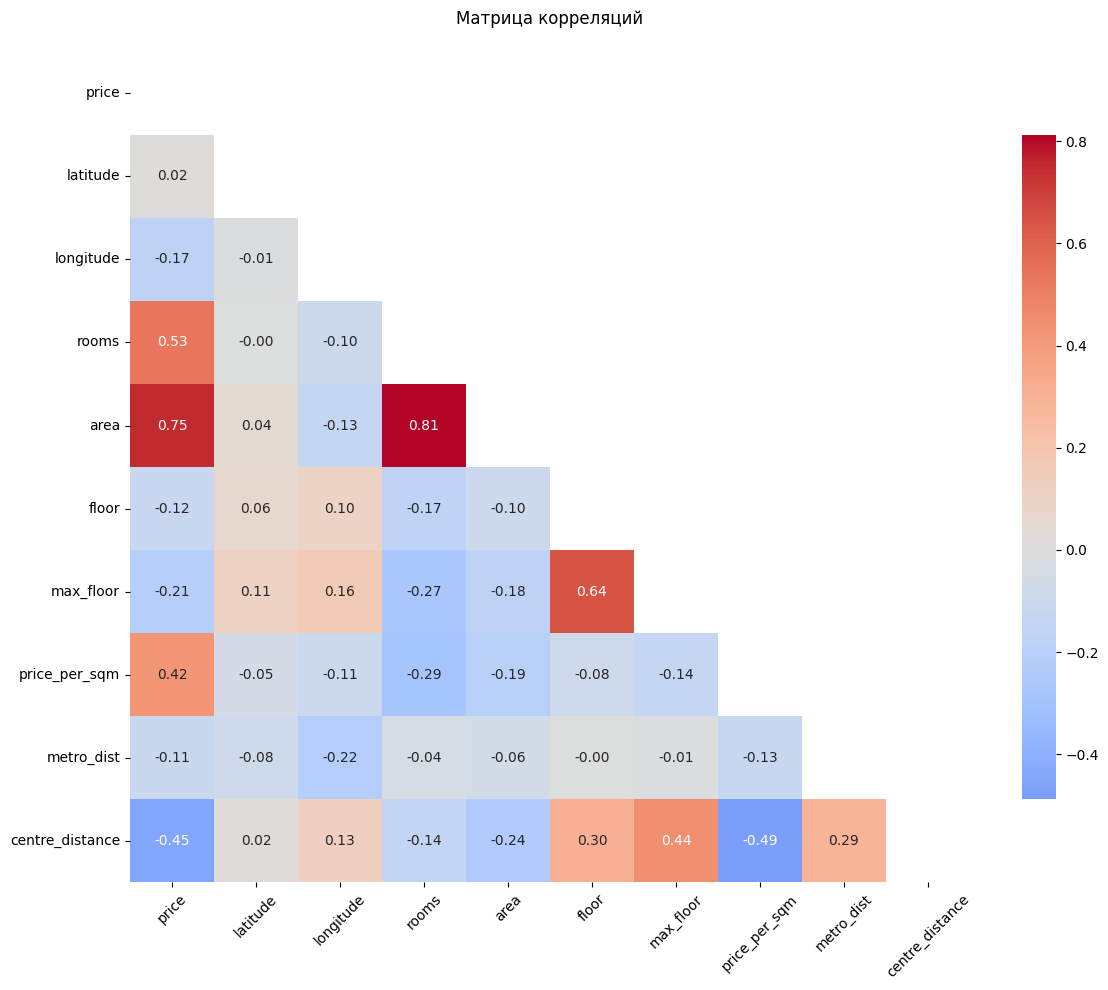

In [ ]:
numeric_cols = offers_filtered.select_dtypes(include=[np.number]).columns.tolist()

numeric_cols = [col for col in numeric_cols if col not in ['id']]

plt.figure(figsize=(12, 10))
corr = offers_filtered[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            annot_kws={"size": 10}, cbar_kws={"shrink": .8})
plt.title("Матрица корреляций", pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Цена:**

Сильно коррелирует с площадью (0.75) и количеством комнат (0.53). Это указывает на то, что более крупные и многокомнатные объекты, как правило, дороже. Умеренная корреляция с ценой за квадратный метр (0.42), что логично, так как цена напрямую зависит от стоимости квадратного метра. Вопреки ожиданиям слабая корреляция с расстоянием до метро (-0.11). Но согласно наблюдениям, умеренная отрицательная корреляция с расстоянием до центра (-0.45), т.е. чем меньше расстояние до центра, тем больше стоимость.

**Площадь:**

Высокая корреляция с количеством комнат (0.81), что ожидаемо, так как большое количество комнат обычно означает большую площадь.

**Этаж и количество этажей:**

Умеренная положительная корреляция между собой (0.64), что тоже вполне логично (чем больше в здании этажей, тем больше может быть этаж объекта).

**Расстояние до центра:**

Умеренная положительная корреляция с этажностью (0.30 и 0.44), так как в центре не строят высокие здания, из-за чего образовалась зависимость. Также небольшая с расстоянием до метро (0.29), так как в центре плотность расположения станций больше и, соответственно, среднее расстояние до ближайшей меньше, чем на окраинах. Умеренная отрицательная корреляция с ценой за метр (-0.49).

Логичнее вместо признака расстояния до метро использовать для предсказания признак расстояния до центра, так как он коррелирует с ценой за квартиру сильнее. Соответственно, тогда выгоднее вернуть те строки исходных данных, у которых не была указана ближайшая станция метро и посчитать расстояние до центра и у них. Таким образом, удастся сохранить часть данных для обучения.

Продолжение в файле "Вторичный анализ.ipynb".
Рассмотрим подробнее зависимость цены от расстояния до центра и сэкономим данные.